<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/20_regularization/20_1_Practical_Training/20_1_4_Saving_and_Checkpointing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regularization: Part 4
## Saving and Checkpointing
---

## What This Notebook Is About

Every model you have trained in this course so far has lived only in memory. Train it, look at the metrics, close the notebook — and it is gone. To use a model tomorrow, or to share it, or to deploy it, you have to be able to write it to disk and load it back. This notebook covers that, and then uses it to build one of the most important techniques in neural network training: **early stopping**.

The two ideas fit together. In 20_1_1 you saw an overfit network whose validation loss reached its best value early and then drifted upward for the rest of training. Dropout *widened* the window of good epochs; a learning rate schedule *stabilized* the endpoint. Early stopping is the final piece: it *captures* the single best epoch by saving the model to disk whenever the validation loss hits a new low, and restores that saved copy at the end. To do that, you first need to know how to save and load.

**What you will learn:**
1. How to save a model's weights with `state_dict()` and `torch.save`
2. How to load them back into a fresh model with `load_state_dict` — and why the architecture must match
3. How to save a full *checkpoint* (model + optimizer + epoch) so training can be resumed
4. How to implement **early stopping** with checkpoint saving — the standard form of model selection
5. Why `weights_only=True` is the safe default when loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import seaborn as sns
sns.set_theme(style='whitegrid')
torch.manual_seed(42)

# Wisconsin Breast Cancer dataset (same as 20_1_1 through 20_1_3)
data  = load_breast_cancer()
X_raw = data.data.astype(np.float32)
y_raw = data.target.astype(np.float32)

X_tmp, X_test_np, y_tmp, y_test_np = train_test_split(
    X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=42
)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=42
)

scaler     = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_val_np   = scaler.transform(X_val_np)
X_test_np  = scaler.transform(X_test_np)

X_train = torch.tensor(X_train_np)
X_val   = torch.tensor(X_val_np)
X_test  = torch.tensor(X_test_np)
y_train = torch.tensor(y_train_np).unsqueeze(1)
y_val   = torch.tensor(y_val_np).unsqueeze(1)
y_test  = torch.tensor(y_test_np).unsqueeze(1)

BATCH_SIZE   = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)

print(f'Train : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')


# The overfit (256, 256) network from 20_1_1 - its early best / late drift is what
# makes it the right showcase for both checkpointing and early stopping.
class OverfitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

Train : 341 samples
Val   : 114 samples
Test  : 114 samples


---

## Section 1: `state_dict()` and `torch.save`

A PyTorch model's learnable state is its collection of parameter tensors — the weights and biases of every layer. `model.state_dict()` returns them as an ordered dictionary mapping each parameter's name to its tensor. You saw `state_dict()` mentioned back in 19_1_1; here we finally write it to disk.

`torch.save(obj, path)` serializes any Python object — a `state_dict` is just a dictionary of tensors — to a file. The convention is to use a `.pt` or `.pth` extension.

In [2]:
torch.manual_seed(42)
model = OverfitNet()

state = model.state_dict()
print('state_dict keys (one weight + one bias per Linear layer):')
for k, v in state.items():
    print(f'  {k:12s}  shape {tuple(v.shape)}')

torch.save(model.state_dict(), 'demo_model.pt')

import os
print(f'\nSaved to demo_model.pt  ({os.path.getsize("demo_model.pt"):,} bytes)')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

state_dict keys (one weight + one bias per Linear layer):
  net.0.weight  shape (256, 30)
  net.0.bias    shape (256,)
  net.2.weight  shape (256, 256)
  net.2.bias    shape (256,)
  net.4.weight  shape (1, 256)
  net.4.bias    shape (1,)

Saved to demo_model.pt  (299,065 bytes)
Total parameters: 73,985


The keys (`net.0.weight`, `net.0.bias`, …) name each parameter by its position in the `Sequential`. The file is essentially a packed copy of those tensors — about 296 KB for this 74,000-parameter network. Nothing about the *architecture* is stored, only the numbers. That detail matters in the next section.

---

## Section 2: Loading a Checkpoint

To load weights back you need two things: a model with the **same architecture**, and the saved file. You construct a fresh model, then call `model.load_state_dict(...)` to copy the saved tensors into it.

Note the `weights_only=True` argument to `torch.load` — we will explain it in Section 6, but make it a habit from the first time you see it. To prove the load worked, we compare a prediction from the freshly loaded model against the original; they should be identical to the last decimal.

In [3]:
# A fresh model starts with random weights - its predictions differ from the saved model
fresh = OverfitNet()
fresh.eval()
model.eval()

sample = X_test[:1]
with torch.no_grad():
    before = fresh(sample).item()

# Load the saved weights into the fresh model
fresh.load_state_dict(torch.load('demo_model.pt', weights_only=True))
with torch.no_grad():
    after    = fresh(sample).item()
    original = model(sample).item()

print(f'Fresh model (random weights)      : {before:.6f}')
print(f'Fresh model after load_state_dict : {after:.6f}')
print(f'Original saved model              : {original:.6f}')
print(f'\nLoaded matches original? {np.isclose(after, original)}')

Fresh model (random weights)      : 0.527577
Fresh model after load_state_dict : 0.504104
Original saved model              : 0.504104

Loaded matches original? True


Before loading, the fresh model's prediction is meaningless — random weights. After `load_state_dict`, it produces *exactly* the original model's output. The weights have been transplanted.

---

## Section 3: The Architecture Must Match

Because the file stores only the numbers and not the structure, the model you load *into* must have the same shapes as the model you saved *from*. If it does not, `load_state_dict` raises a `RuntimeError` describing the mismatch — a good error to recognize, because it usually means the architecture in your loading code has drifted from the one you trained.

In [4]:
# Same key structure (a .net Sequential) but a different hidden width: 128, not 256
class WrongWidthNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


wrong_arch = WrongWidthNet()

try:
    wrong_arch.load_state_dict(torch.load('demo_model.pt', weights_only=True))
except RuntimeError as e:
    print('RuntimeError (expected):\n')
    # show just the first couple of mismatch lines
    print('\n'.join(str(e).splitlines()[:3]))

RuntimeError (expected):

Error(s) in loading state_dict for WrongWidthNet:
	size mismatch for net.0.weight: copying a param with shape torch.Size([256, 30]) from checkpoint, the shape in current model is torch.Size([128, 30]).
	size mismatch for net.0.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([128]).


The error names the exact tensor that does not fit: the saved `net.0.weight` is `[256, 30]`, but this model's first layer wants `[128, 30]`. The fix is always the same — make the loading architecture identical to the one that was saved.

---

## Section 4: Saving a Full Training State

Sometimes you want to *resume* training later, not just reload final weights — for example after a long run is interrupted. To resume cleanly you need more than the model weights: you need the **optimizer's** state too (Adam keeps running averages per parameter), and bookkeeping like the epoch number and best loss so far.

The idiom is to save a dictionary bundling everything:

In [5]:
torch.manual_seed(42)
model     = OverfitNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ... imagine some training happened, reaching epoch 42 ...
checkpoint = {
    'model':     model.state_dict(),
    'optimizer': optimizer.state_dict(),
    'epoch':     42,
    'val_loss':  0.0513,
}
torch.save(checkpoint, 'full_checkpoint.pt')

# Resuming: load the dict, then restore each piece into a fresh model + optimizer
ckpt       = torch.load('full_checkpoint.pt', weights_only=True)
resume_model = OverfitNet()
resume_optim = torch.optim.Adam(resume_model.parameters(), lr=1e-3)
resume_model.load_state_dict(ckpt['model'])
resume_optim.load_state_dict(ckpt['optimizer'])

print('Checkpoint contents:', list(ckpt.keys()))
print(f"Saved at epoch {ckpt['epoch']} with val_loss {ckpt['val_loss']:.4f}")
print(f"Would resume training from epoch {ckpt['epoch'] + 1}")

Checkpoint contents: ['model', 'optimizer', 'epoch', 'val_loss']
Saved at epoch 42 with val_loss 0.0513
Would resume training from epoch 43


For simply *using* a trained model you only need the `state_dict`; the full dictionary is for *resuming* an interrupted run. The next section uses the lighter form — saving just the weights of the best epoch.

---

## Section 5: Early Stopping with Checkpoint Saving

Now the payoff. Recall the problem from 20_1_1: train the overfit network long enough and its validation loss bottoms out early, then climbs as the model starts memorizing. We have no way to know the best epoch in advance — but we *can* watch the validation loss and save a copy of the model every time it reaches a new low.

That is **early stopping with checkpointing**, and it does two jobs at once:

- **Checkpointing** — whenever validation loss improves, overwrite a saved `best_model.pt`. By the end of training, that file holds the weights from the single best epoch, no matter when it occurred.
- **Early stopping** — if validation loss fails to improve for `patience` consecutive epochs, stop training. There is no point burning compute to overfit further.

First, let's see the problem this solves by training the full 300 epochs *without* stopping, saving the best checkpoint as we go:

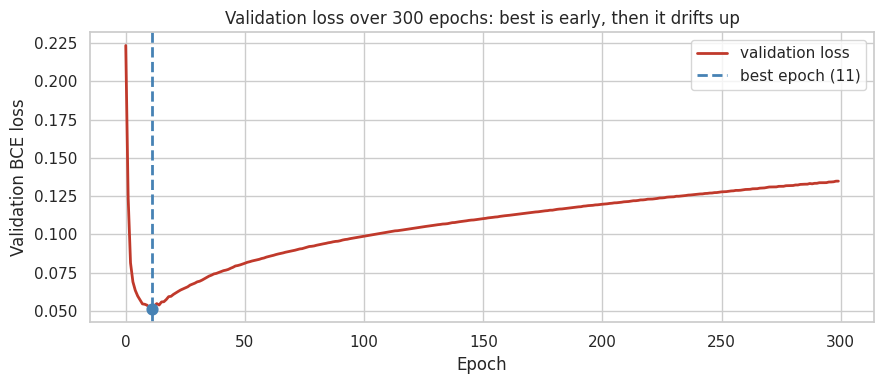

Best validation loss : 0.0513  at epoch 11
Final validation loss : 0.1348  at epoch 299

Training the full 300 epochs left us 0.0835 worse than
the best epoch. The checkpoint at best_model.pt holds those best weights.


In [6]:
torch.manual_seed(42)
model     = OverfitNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

val_history   = []
best_val      = float('inf')
best_epoch    = -1

for epoch in range(300):
    model.train()
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val), y_val).item()
    val_history.append(val_loss)

    if val_loss < best_val:                       # new best -> save a checkpoint
        best_val   = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_model.pt')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(val_history, color='#C0392B', lw=2, label='validation loss')
ax.axvline(best_epoch, color='steelblue', linestyle='--', lw=2,
           label=f'best epoch ({best_epoch})')
ax.scatter([best_epoch], [best_val], color='steelblue', s=60, zorder=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation BCE loss')
ax.set_title('Validation loss over 300 epochs: best is early, then it drifts up')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best validation loss : {best_val:.4f}  at epoch {best_epoch}')
print(f'Final validation loss : {val_history[-1]:.4f}  at epoch 299')
print(f'\nTraining the full 300 epochs left us {val_history[-1] - best_val:.4f} worse than')
print(f'the best epoch. The checkpoint at best_model.pt holds those best weights.')

The curve is the 20_1_1 story again: the best epoch comes early, and everything after is wasted at best and harmful at worst. The blue marker is the model we actually want — and because we checkpointed it, `best_model.pt` already holds exactly those weights.

So two things are clear. First, we should **stop** once it is obvious the model is only getting worse. Second, we should **restore** the checkpointed best weights rather than keep whatever the last epoch produced. Here is the complete pattern with both:

In [7]:
torch.manual_seed(42)
model     = OverfitNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

MAX_EPOCHS = 300
PATIENCE   = 20            # stop after 20 epochs with no improvement

best_val          = float('inf')
best_epoch        = -1
patience_counter  = 0

for epoch in range(MAX_EPOCHS):
    model.train()
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val), y_val).item()

    if val_loss < best_val:
        best_val         = val_loss
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')   # checkpoint the new best
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}: no improvement for {PATIENCE} epochs.')
        break

# Restore the best checkpoint - NOT whatever the last epoch left behind
model.load_state_dict(torch.load('best_model.pt', weights_only=True))

print(f'Best epoch          : {best_epoch}  (val loss {best_val:.4f})')
print(f'Stopped at epoch    : {epoch}  (saved {epoch - best_epoch} epochs of needless training)')
print(f'Restored model is the one from epoch {best_epoch}.')

Early stopping at epoch 31: no improvement for 20 epochs.
Best epoch          : 11  (val loss 0.0513)
Stopped at epoch    : 31  (saved 20 epochs of needless training)
Restored model is the one from epoch 11.


Early stopping triggered far short of 300 epochs: training halted once the validation loss had failed to beat its record for `PATIENCE` epochs in a row. The `patience` parameter is the one knob — too small and normal epoch-to-epoch noise stops you prematurely; too large and you waste compute. Values of 10–25 are common.

The crucial last line is `load_state_dict`. When training stops, the model in memory is from the *stopping* epoch, which is `PATIENCE` epochs past the best one and therefore worse. Loading `best_model.pt` rewinds it to the genuinely best weights. **Early stopping without restoring the checkpoint gives you the wrong model** — a subtle but real mistake.

---

## Section 6: Why `weights_only=True`

You have seen `weights_only=True` on every `torch.load` call. Here is the reason. `torch.save` is built on Python's `pickle`, and unpickling an untrusted file can execute arbitrary code hidden inside it. Loading a model someone emailed you, or pulled from the internet, is a genuine security risk.

`weights_only=True` tells PyTorch to load *only* tensors and a few safe primitive types, refusing anything that could run code. In PyTorch 2.x it is the recommended default, and as of recent versions it is becoming the default behavior. Use it for every load — it costs nothing when the file is your own and protects you when it is not.

---

## Section 7: Final Evaluation on the Test Set

The model in memory is already the restored best checkpoint from Section 5. We evaluate it once on the untouched **test set**.

In [8]:
model.eval()
with torch.no_grad():
    test_preds  = (model(X_test) > 0.5).long().squeeze().numpy()
    test_labels = y_test.long().squeeze().numpy()

print(f'Final model: best checkpoint from epoch {best_epoch} (early stopped)')
print()
print(classification_report(test_labels, test_preds, target_names=data.target_names, digits=3))

# Clean up the demo files
import os
for f in ('demo_model.pt', 'full_checkpoint.pt', 'best_model.pt'):
    if os.path.exists(f):
        os.remove(f)
print('Cleaned up demo .pt files.')

Final model: best checkpoint from epoch 11 (early stopped)

              precision    recall  f1-score   support

   malignant      0.930     0.952     0.941        42
      benign      0.972     0.958     0.965        72

    accuracy                          0.956       114
   macro avg      0.951     0.955     0.953       114
weighted avg      0.957     0.956     0.956       114

Cleaned up demo .pt files.


---

## Putting It All Together

| Concept | What it means |
|---|---|
| `model.state_dict()` | Ordered dict of all parameter tensors (weights and biases) |
| `torch.save(obj, path)` | Serialize a state_dict (or any object) to disk; use a `.pt` extension |
| `load_state_dict(...)` | Copy saved tensors into a model — architecture must match exactly |
| Architecture mismatch | A shape disagreement raises `RuntimeError`; fix by matching the structure |
| Full checkpoint | `{'model', 'optimizer', 'epoch', ...}` — everything needed to *resume* training |
| Early stopping | Halt once validation loss stops improving for `patience` epochs |
| Checkpoint saving | Overwrite `best_model.pt` whenever validation loss hits a new low |
| Restore the best | After stopping, `load_state_dict` the checkpoint — not the last epoch's weights |
| `weights_only=True` | Safe default for `torch.load`; refuses to execute code hidden in the file |

**The habits to lock in:** save the best checkpoint during training, not just at the end; always restore it after early stopping; and load with `weights_only=True`.

**What is coming next:** Notebook 20_1_5 assembles the whole module — dropout, batch normalization, a learning rate schedule, and early stopping with checkpointing — into one reusable `train_model()` function, and runs an ablation to see how much each technique contributes.